In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
with open('/u/rfechner/data/incomplete_reasoning_strategies/deltas.jsonl', 'r') as file:
    rs = pd.read_json(file, lines=True)

with open('/u/rfechner/data/incomplete_reasoning_types/deltas.jsonl', 'r') as file:
    rt = pd.read_json(file, lines=True)

In [8]:
rs['ans_char_len'] = rs['prompt'].apply(lambda x: len(x[1]['content']))
rt['ans_char_len'] = rt['prompt'].apply(lambda x: len(x[1]['content']))

Dropping: 17


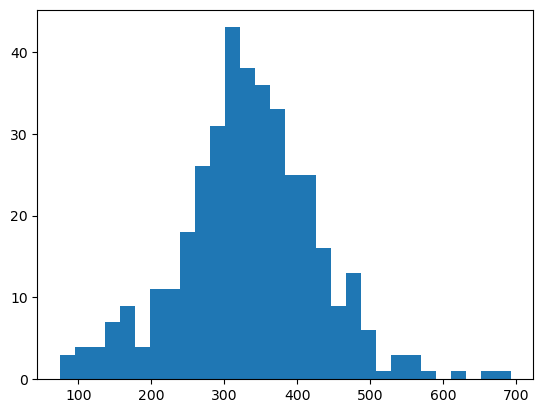

Dropping: 26


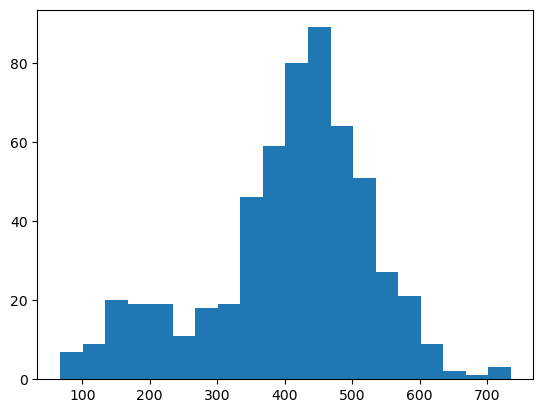

In [19]:
import matplotlib.pyplot as plt
def filter_short_long(s : pd.Series, low=50, high=1000):
    mask = (s > low) & (s < high)
    print(f"Dropping: {sum(~mask)}")
    return s[mask]

plt.hist(filter_short_long(rs['ans_char_len']), bins=30)
plt.show()

plt.hist(filter_short_long(rt['ans_char_len']), bins=20)
plt.show()

In [27]:
low, high=20, 1000
rsmask, rtmask = (rs['ans_char_len'] > low) & (rs['ans_char_len'] < high), (rt['ans_char_len'] > low) & (rt['ans_char_len'] < high)
rsin, rsout = rs[rsmask], rs[~rsmask]
rtin, rtout = rt[rtmask], rt[~rtmask]

In [28]:
rsout['prompt'].apply(lambda x: x[1]['content'])

16     6\n[TASK] Take the ground truth response and a...
29                                                67,500
30                                                67,500
83                                                    42
104                                                   14
105                                                   14
106                                                   14
110                                                   14
162                                                  121
258                                                   13
269                                                  450
275    3200\n[TASK] Take the ground truth response an...
302                                                  150
345                                                 5250
352                                                  160
358                                                  160
372                                                  300
Name: prompt, dtype: object

In [24]:
rtout['prompt'].apply(lambda x: x[1]['content'])

1      67,500
37         60
118        46
191       347
216      5250
217      5250
273        44
281        72
308       155
335       290
377       125
380      8900
390         7
423        80
430         2
432         2
433         2
473         7
475        14
476        14
497        25
522         4
525        60
527        60
557        20
580        11
Name: prompt, dtype: object

In [33]:
iter_dataframe = rsin.reset_index(drop=True)
for i, row in iter_dataframe.iterrows():
    print(f"Behaviour: {row['behaviour_type']}")
    print(f"Prompt: {row['prompt'][0]['content']}")
    print(f"GT: {row['prompt'][1]['content']}")
    if i > 10:
        break

Behaviour: Pattern Recognition
Prompt: John decides to start collecting art. He pays the same price for his first 3 pieces of art and the total price came to $45,000. The next piece of art was 50% more expensive than those. How much did all the art cost?
GT: I notice a pattern in the pricing: the first three pieces have equal cost ($45,000 total means $15,000 each). This uniform pricing pattern breaks for the fourth piece, which is 50% more expensive ($22,500). Recognizing this shift from uniform pricing to a percentage-based increase reveals the total cost structure. The final answer is \boxed{67500}.
Behaviour: Backtracking
Prompt: John decides to start collecting art. He pays the same price for his first 3 pieces of art and the total price came to $45,000. The next piece of art was 50% more expensive than those. How much did all the art cost?
GT: Let me calculate the cost of the first three pieces: $45,000 ÷ 3 = $15,000 each. Now, trying to calculate the fourth piece: if I mistakenl